## Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

## Loading dataset

In [22]:
df = pd.read_csv("../../Data/Processed/Master/featured_dataset.csv")

print(df.shape)
df.head()

(98914, 50)


,RaceID,Year,RaceName,Circuit,Driver,Team,LapNumber,Position,LapTime_Seconds,Compound,...,IsOldTire,IsLongStint,DegradationRate,LapLengthFactor,CornerDensity,DRS_per_km,TempDifference,IsHotTrack,IsHotAir,TempCategory
0,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,1,17.0,100.625,MEDIUM,...,False,False,NaN,1.0446,3.0297,0.3787,6.6,False,False,Medium
1,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,2,18.0,93.560,MEDIUM,...,False,False,NaN,1.0446,3.0297,0.3787,6.6,False,False,Medium
2,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,3,18.0,91.768,MEDIUM,...,False,False,-4.0,1.0446,3.0297,0.3787,6.7,False,False,Medium
3,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,4,18.0,91.591,MEDIUM,...,False,False,-3.0,1.0446,3.0297,0.3787,6.1,False,False,Medium
4,ABU23,2023,Abu Dhabi Grand Prix,Yas Island,ALB,Williams,5,18.0,91.422,MEDIUM,...,False,False,-2.0,1.0446,3.0297,0.3787,6.0,False,False,Medium


## Keeping only valid laps

In [23]:
df = df[df["ValidLap"]].copy()

## Dropping metadata colimns &  Chosing target

In [24]:
metadata_cols = [
    "RaceID",
    "RaceName",
    "ValidLap",
    "ExclusionReason"
]

leakage_cols = [
    "LapDelta",
    "DegradationRate",
    "PitInTime",
    "PitOutTime"
]

target = "LapTime_Seconds"

## Spliting data

In [25]:
df = df.drop(columns=metadata_cols)

train_df = df[df["Year"] < 2025].copy()
test_df = df[df["Year"] == 2025].copy()

X_train = train_df.drop(columns=[target] + leakage_cols)
y_train = train_df[target]

X_test = test_df.drop(columns=[target] + leakage_cols)
y_test = test_df[target]

## Encoding Catgoricals

In [26]:
cat_cols = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns

print(cat_cols.tolist())

['Circuit', 'Driver', 'Team', 'Compound', 'Direction', 'HighSpeedCircuit', 'SurfaceAbrasion', 'IsFinal10Laps', 'RaceHalf', 'IsFreshTire', 'IsOldTire', 'IsLongStint', 'IsHotTrack', 'IsHotAir', 'TempCategory']


In [27]:
X_train = pd.get_dummies(
    X_train,
    columns=cat_cols
)

X_test = pd.get_dummies(
    X_test,
    columns=cat_cols
)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [28]:
train_mask = X_train.notna().all(axis=1)
X_train = X_train[train_mask]
y_train = y_train[train_mask]

test_mask = X_test.notna().all(axis=1)
X_test = X_test[test_mask]
y_test = y_test[test_mask]

In [30]:
print(X_train.shape)
print(X_test.shape)

print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

(67850, 121)
(24985, 121)
0
0


## Baseline models

Linear Regression

In [36]:
LR = LinearRegression()

LR.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
Pred_LR = LR.predict(X_test)

In [38]:
mae_LR = mean_absolute_error(y_test, Pred_LR)
rmse_LR = np.sqrt(mean_squared_error(y_test, Pred_LR))
r2_LR = r2_score(y_test, Pred_LR)

print(f"MAE : {mae_LR:.4f}")
print(f"RMSE: {rmse_LR:.4f}")
print(f"R²  : {r2_LR:.4f}")

MAE : 3.1491
RMSE: 6.6772
R²  : 0.7414


Random Forest

In [39]:
RF = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
RF.fit(X_train, y_train)

Pred_RF = RF.predict(X_test)

In [40]:
mae_RF = mean_absolute_error(y_test, Pred_RF)
rmse_RF = np.sqrt(mean_squared_error(y_test, Pred_RF))
r2_RF = r2_score(y_test, Pred_RF)

print(f"MAE : {mae_RF:.4f}")
print(f"RMSE: {rmse_RF:.4f}")
print(f"R²  : {r2_RF:.4f}")

MAE : 3.0981
RMSE: 6.7979
R²  : 0.7319


Gradient Boosting

In [41]:
GB = GradientBoostingRegressor(
    random_state=42
)

GB.fit(X_train, y_train)

Pred_GB = GB.predict(X_test)

In [42]:
mae_GB = mean_absolute_error(y_test, Pred_GB)
rmse_GB = np.sqrt(mean_squared_error(y_test, Pred_GB))
r2_GB = r2_score(y_test, Pred_GB)

print(f"MAE : {mae_GB:.4f}")
print(f"RMSE: {rmse_GB:.4f}")
print(f"R²  : {r2_GB:.4f}")

MAE : 2.4780
RMSE: 5.9166
R²  : 0.7969


## Compareing Models

In [43]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_LR,
        mae_RF,
        mae_GB
    ],
    "RMSE": [
        rmse_LR,
        rmse_RF,
        rmse_GB
    ],
    "R2": [
        r2_LR,
        r2_RF,
        r2_GB
    ]
})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,Gradient Boosting,2.477965,5.916642,0.796937
0,Linear Regression,3.149055,6.677166,0.741379
1,Random Forest,3.098130,6.797930,0.731939


## Feature Importance

In [44]:
importance = pd.Series(
    RF.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(20)

PrevLapTime           0.750004
RollingMean3          0.034897
TireLifePercentage    0.025347
RollingMean5          0.015722
TireAge               0.015174
TempDifference        0.014137
PaceTrend             0.013905
PrevLapTime2          0.013562
TrackTemp             0.011396
AirTemp               0.010774
RemainingLaps         0.009938
RaceProgress          0.009744
RollingStd5           0.007983
LapNumber             0.007902
Position              0.006244
Corners               0.005456
TotalRaceLaps         0.004850
DRS_per_km            0.004285
CornerDensity         0.003004
Year                  0.002489
dtype: float64

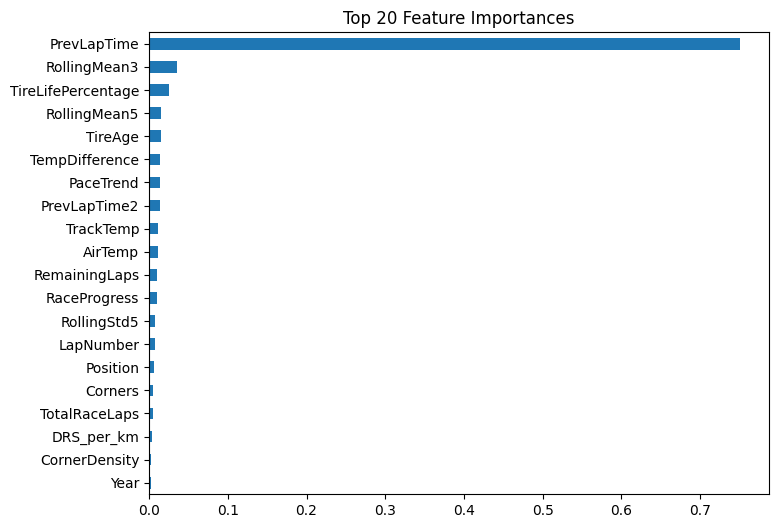

In [45]:
importance.head(20).plot.barh(figsize=(8,6))
plt.title("Top 20 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

## Expriment 1

In [46]:
X_train_exp = X_train.copy()
X_test_exp = X_test.copy()

In [47]:
history_features = [
    "PrevLapTime",
    "PrevLapTime2",
    "RollingMean3",
    "RollingMean5",
    "RollingStd5",
    "PaceTrend"
]

X_train_exp = X_train_exp.drop(columns=history_features)
X_test_exp = X_test_exp.drop(columns=history_features)

In [48]:
gb_no_history = GradientBoostingRegressor(
    random_state=42
)

gb_no_history.fit(X_train_exp, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [49]:
pred_no_history = gb_no_history.predict(X_test_exp)

mae_no_history = mean_absolute_error(y_test, pred_no_history)
rmse_no_history = np.sqrt(mean_squared_error(y_test, pred_no_history))
r2_no_history = r2_score(y_test, pred_no_history)

print(f"MAE : {mae_no_history:.4f}")
print(f"RMSE: {rmse_no_history:.4f}")
print(f"R²  : {r2_no_history:.4f}")

MAE : 4.8974
RMSE: 8.4877
R²  : 0.5821


In [50]:
comparison = pd.DataFrame({
    "Model": [
        "Gradient Boosting (Full)",
        "Gradient Boosting (No Pace History)"
    ],
    "MAE": [
        mae_GB,
        mae_no_history
    ],
    "RMSE": [
        rmse_GB,
        rmse_no_history
    ],
    "R²": [
        r2_GB,
        r2_no_history
    ]
})

display(comparison)

,Model,MAE,RMSE,R²
0,Gradient Boosting (Full),2.477965,5.916642,0.796937
1,Gradient Boosting (No Pace History),4.897447,8.487736,0.582109


In [52]:
importances = pd.Series(
    gb_no_history.feature_importances_,
    index=X_train_exp.columns
).sort_values(ascending=False)

importances = pd.Series(
    gb_no_history.feature_importances_,
    index=X_train_exp.columns
).sort_values(ascending=False)

display(importances.head(20))

display(importances.head(20))

TotalRaceLaps            0.278510
LapLengthFactor          0.126156
Corners                  0.118648
Length_km                0.107102
TireAge                  0.052724
DRS_per_km               0.034831
TireLifePercentage       0.028987
Compound_INTERMEDIATE    0.027576
TempDifference           0.024759
CornerDensity            0.021260
AirTemp                  0.019958
Year                     0.015406
TrackTemp                0.013988
LapNumber                0.013443
HighSpeedCircuit_No      0.012532
Circuit_Spielberg        0.012481
Circuit_Shanghai         0.011095
Rainfall                 0.010702
RemainingLaps            0.009748
RaceProgress             0.008489
dtype: float64

TotalRaceLaps            0.278510
LapLengthFactor          0.126156
Corners                  0.118648
Length_km                0.107102
TireAge                  0.052724
DRS_per_km               0.034831
TireLifePercentage       0.028987
Compound_INTERMEDIATE    0.027576
TempDifference           0.024759
CornerDensity            0.021260
AirTemp                  0.019958
Year                     0.015406
TrackTemp                0.013988
LapNumber                0.013443
HighSpeedCircuit_No      0.012532
Circuit_Spielberg        0.012481
Circuit_Shanghai         0.011095
Rainfall                 0.010702
RemainingLaps            0.009748
RaceProgress             0.008489
dtype: float64

# Conclusion

Removing all pace-history features reduced model performance from an R² of 0.797 to 0.582, demonstrating that previous lap performance is the strongest predictor of future lap times. However, tyre condition, weather, and circuit characteristics still explained over half of the lap-time variability, highlighting their importance in race strategy modeling.

## Experiment 2

In [68]:
X_train_exp = X_train.copy()
X_test_exp = X_test.copy()

In [69]:
history_features = [
    "TotalRaceLaps",
    "Length_km",
    "LapLengthFactor",
    "PrevLapTime",
    "PrevLapTime2",
    "RollingMean3",
    "RollingMean5",
    "RollingStd5",
    "PaceTrend"
]

X_train_exp2 = X_train.drop(columns=history_features)
X_test_exp2 = X_test.drop(columns=history_features)

In [74]:
gb_no_Lapinfo = GradientBoostingRegressor(
    random_state=42
)

gb_no_Lapinfo.fit(X_train_exp2, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [75]:
pred_no_Lapinfo = gb_no_Lapinfo.predict(X_test_exp2)

mae_no_Lapinfo = mean_absolute_error(y_test, pred_no_Lapinfo)
rmse_no_Lapinfo = np.sqrt(mean_squared_error(y_test, pred_no_Lapinfo))
r2_no_Lapinfo = r2_score(y_test, pred_no_Lapinfo)

print(f"MAE : {mae_no_Lapinfo:.4f}")
print(f"RMSE: {rmse_no_Lapinfo:.4f}")
print(f"R²  : {r2_no_Lapinfo:.4f}")

MAE : 4.7824
RMSE: 8.4675
R²  : 0.5841


In [76]:
comparisons = pd.DataFrame({
    "Model": [
        "Gradient Boosting (Full)",
        "Gradient Boosting (No Pace History)",
        "Gradient Boosting (No Pace History) &(no race-length/circuit-length proxy features)"
    ],
    "MAE": [
        mae_GB,
        mae_no_history,
        mae_no_Lapinfo
    ],
    "RMSE": [
        rmse_GB,
        rmse_no_history,
        rmse_no_Lapinfo
    ],
    "R²": [
        r2_GB,
        r2_no_history,
        r2_no_Lapinfo   
    ]
})

display(comparisons)

,Model,MAE,RMSE,R²
0,Gradient Boosting (Full),2.477965,5.916642,0.796937
1,Gradient Boosting (No Pace History),4.897447,8.487736,0.582109
2,Gradient Boosting (No Pace History) &(no race-...,4.782388,8.467539,0.584095


In [78]:
importances = pd.Series(
    gb_no_Lapinfo.feature_importances_,
    index=X_train_exp2.columns
).sort_values(ascending=False)

display(importances.head(20))

Corners                  0.440031
CornerDensity            0.163591
TireAge                  0.074997
TempDifference           0.044795
Circuit_São Paulo        0.044076
AirTemp                  0.034203
TrackTemp                0.026972
DRS_per_km               0.021638
Circuit_Spielberg        0.021197
Circuit_Marina Bay       0.019900
Compound_INTERMEDIATE    0.014710
LapNumber                0.011770
Year                     0.010118
Circuit_Shanghai         0.009822
RemainingLaps            0.009123
RaceProgress             0.007916
TireLifePercentage       0.007792
Circuit_Lusail           0.005088
Rainfall                 0.005086
AvgCompoundLife          0.004995
dtype: float64

# conclusion

An ablation study was conducted to evaluate the contribution of different feature groups. Removing pace-history features reduced the model's R² from 0.797 to 0.582, demonstrating that recent lap performance is the strongest predictor of future lap time. Removing race-length proxy features in addition to pace-history features resulted in a negligible change (R² = 0.584), indicating that the model did not rely excessively on these variables and instead adapted by leveraging circuit geometry, tyre state, and weather information.